# data_transform_new

Notebook copy of `data_transform_new.py`.

## Shared Imports
Common imports and dependencies used across the notebook.

In [1]:
# Imports and shared dependencies

import os
import time
from collections import defaultdict
from typing import Optional, Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


## Data Loading and Feature Engineering
Transforms raw step logs into model-ready features.

In [2]:
# Data loading and feature engineering

def load_and_transform(path: str) -> pd.DataFrame:
    """Load a stats.json file and compute derived fields."""
    df = pd.read_json(path, lines=True)
    df["source_file"] = path

    start_rows = []
    confidence_cols = [
        "output_min_confidence",
        "output_q25_confidence",
        "output_median_confidence",
        "output_avg_confidence",
        "output_q75_confidence",
        "min_confidence",
        "q25_confidence",
        "median_confidence",
        "avg_confidence",
        "q75_confidence",
    ]
    for _, group in df.groupby("id", sort=False):
        start_row = group.iloc[0].copy()
        start_row["num_denoise_ran"] = 0
        start_row["num_unmasked_tokens"] = 0
        start_row["num_cur_unmasked_tokens"] = 0
        start_row["block"] = 0
        start_row["block_num_denoise_ran"] = 0
        start_row["block_num_unmasked_tokens"] = 0
        start_row["confidence_threshold"] = group.iloc[0]["confidence_threshold"]
        if "max_confidence_threshold" in start_row.index:
            start_row["max_confidence_threshold"] = group.iloc[0]["max_confidence_threshold"]
        for column in confidence_cols:
            if column in start_row.index:
                start_row[column] = 0
        start_rows.append(start_row)

    if start_rows:
        df = pd.concat([pd.DataFrame(start_rows), df], ignore_index=True)

    df["full_progress"] = (df["num_denoise_ran"] + 1) / df["output_length"]
    df["full_unmask_progress"] = df["num_unmasked_tokens"] / df["output_length"]
    df["block_progress"] = df["block"] / (df["output_length"] / df["block_size"] )
    df["block_unmask_progress"] = df["block_num_unmasked_tokens"] / df["block_size"]
    final_denoise = df.groupby("id")["num_denoise_ran"].transform("max")
    df["denoise_ratio"] = (final_denoise - df["num_denoise_ran"]) / df["output_length"]
    df["num_denoise_left"] = final_denoise - df["num_denoise_ran"]
    df = df.sort_values(["id", "num_denoise_ran"]).reset_index(drop=True)
    df["num_cur_unmasked_tokens"] = df.groupby("id")["num_unmasked_tokens"].diff().fillna(df["num_unmasked_tokens"] )
    df["full_cur_unmask_progress"] = df["num_cur_unmasked_tokens"] / df["output_length"]
    df["last_recompute_avg_output_confidence"] = df["avg_confidence"]
    df["cur_avg_output_confidence"] = df["avg_confidence"]

    return df[[
        "source_file",
        "id",
        "confidence_threshold",
        "num_unmasked_tokens",
        "num_cur_unmasked_tokens",
        "output_length",
        "block_size",
        "block",
        "block_num_unmasked_tokens",
        "num_denoise_ran",
        "num_denoise_left",
        "full_progress",
        "full_unmask_progress",
        "full_cur_unmask_progress",
        "block_progress",
        "block_unmask_progress",
        "denoise_ratio",
        "last_recompute_avg_output_confidence",
        "cur_avg_output_confidence",
        "output_min_confidence",
        "output_q25_confidence",
        "output_median_confidence",
        "output_avg_confidence",
        "output_q75_confidence",
    ]]


def mape_objective(y_pred, dataset):
    """Custom MAPE objective for LightGBM."""
    y_true = dataset.get_label()
    eps = 1e-6
    grad = np.sign(y_pred - y_true) / (np.abs(y_true) + eps)
    hess = np.ones_like(y_true) / (np.abs(y_true) + eps)
    return grad, hess


def mape_metric(y_pred, dataset):
    """MAPE metric for LightGBM."""
    y_true = dataset.get_label()
    eps = 1e-6
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + eps)))
    return "mape", mape, False


## Confidence Helpers
Functions for deriving confidence-based statistics and histograms from step data.

In [3]:
# Confidence and histogram helpers

def compute_masked_confidence(df: pd.DataFrame):
    masked_conf_avgs = []
    for rid, group in df.groupby("id"):
        group = group.sort_values("num_denoise_ran")
        cumulative_unmasked = set()
        for _, row in group.iterrows():
            output_len = row["output_length"]
            conf = row["confidences"][-output_len:]
            prompt_len = len(row["confidences"]) - output_len
            newly = row["cur_tokens_unmasked"]
            cumulative_unmasked |= set(newly)
            masked_positions = [i for i in range(output_len) if prompt_len + i not in cumulative_unmasked]
            if len(masked_positions) == 0:
                masked_conf_avgs.append(1)
            else:
                vals = [conf[i] for i in masked_positions]
                masked_conf_avgs.append(float(np.mean(vals)))
    df["masked_conf_avg"] = masked_conf_avgs
    return df


def compute_output_confidence(df: pd.DataFrame):
    masked_conf_avgs = []
    for rid, group in df.groupby("id"):
        group = group.sort_values("num_denoise_ran")
        cumulative_unmasked = set()
        for _, row in group.iterrows():
            output_len = row["output_length"]
            conf = row["confidences"][-output_len:]
            newly = row["cur_tokens_unmasked"]
            cumulative_unmasked |= set(newly)
            masked_conf_avgs.append(float(np.mean(conf)))
    df["output_conf_avg"] = masked_conf_avgs
    return df


def compute_all_confidence_stats(df: pd.DataFrame):
    min_confidences = []
    max_confidences = []
    lower_quartile_confidences = []
    upper_quartile_confidences = []
    mean_confidences = []
    median_confidences = []

    for _, row in df.iterrows():
        output_len = row["output_length"]
        conf = row["confidences"][-output_len:]
        min_confidences.append(float(np.min(conf)))
        max_confidences.append(float(np.max(conf)))
        lower_quartile_confidences.append(float(np.percentile(conf, 25)))
        upper_quartile_confidences.append(float(np.percentile(conf, 75)))
        mean_confidences.append(float(np.mean(conf)))
        median_confidences.append(float(np.median(conf)))

    df["min_all_confidence"] = min_confidences
    df["max_all_confidence"] = max_confidences
    df["lower_quartile_all_confidence"] = lower_quartile_confidences
    df["upper_quartile_all_confidence"] = upper_quartile_confidences
    df["mean_all_confidence"] = mean_confidences
    df["median_all_confidence"] = median_confidences
    return df


def plot_final_denoise_histogram(path: list[str]) -> None:
    """Plot histogram of final denoise steps per sequence."""
    df = pd.concat([pd.read_json(p, lines=True) for p in path], ignore_index=True)
    final_denoise = df.groupby("id")["num_denoise_ran"].max()
    final_denoise_ratio = final_denoise / df.groupby("id")["output_length"].first()
    print(f"average final denoise ratio: {final_denoise_ratio.mean():.4f}")
    plt.figure(figsize=(6, 4))
    plt.hist(final_denoise_ratio, bins=30, edgecolor='black', alpha=0.7)
    plt.xlim(0, 1)
    plt.xlabel("# Denoise Steps / Output Length")
    plt.ylabel("Count")
    plt.title("GSM8K")
    plt.tight_layout()
    plt.savefig("final_denoise_histogram.png", dpi=300)


## Pipeline Helpers
Prepare the merged frame, split IDs, and build train/test matrices once so the later cells stay small.

In [4]:
# Shared pipeline helpers

def normalize_paths(path: Optional[Union[str, list[str]]]) -> list[str] | None:
    if path is None:
        return None
    return [path] if isinstance(path, str) else list(path)


def get_default_included_features() -> list[str]:
    return [
        "full_progress",
        "full_unmask_progress",
        "confidence_threshold",
        "output_min_confidence",
        "output_q25_confidence",
        "output_median_confidence",
        "output_avg_confidence",
        "output_q75_confidence",
    ]






## Usage Inputs

In [5]:
# Usage example
train_paths = [
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/100005/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/105508/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/110208/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/110854/step_data.json",
    "/work/hdd/bftv/tchang85/step_predictor_dataset/sharegpt_gpt4_clean_train/20260413/111455/step_data.json",
]
test_paths = None
included_features = [
    "full_progress",
    "full_unmask_progress",
    "block_progress",
    "block_unmask_progress",
    "confidence_threshold",
    "output_min_confidence",
    "output_q25_confidence",
    "output_median_confidence",
    "output_avg_confidence",
    "output_q75_confidence",
    # "output_length",
]
objective = "denoise_ratio"
model_name = "sharegpt_0423_all_features_no_output_length"
model_type = "lightgbm"
# model_params = {
#     "n_estimators": 2000,
#     "learning_rate": 0.025,
#     "max_depth": 10,
#     "subsample": 0.85,
#     "colsample_bytree": 0.85,
#     "reg_alpha": 0.1,
#     "reg_lambda": 1.5,
# }
save_model = True
save_results = False


## Input Prepping

### Functions

In [6]:
def make_dataset_frame(train_path: Union[str, list[str]],
                       test_path: Optional[Union[str, list[str]]] = None) -> tuple[pd.DataFrame, list[str], list[str] | None]:
    train_paths = normalize_paths(train_path)
    test_paths = normalize_paths(test_path)
    all_paths = [*train_paths, *(test_paths if test_paths else [])]
    df = pd.concat([load_and_transform(p) for p in all_paths], ignore_index=True)
    df["id"] = df["source_file"] + "_" + df["id"].astype(str)
    return df, train_paths, test_paths


def make_id_splits(df: pd.DataFrame,
                   train_paths: list[str],
                   test_paths: list[str] | None = None,
                   test_size: float = 0.2,
                   random_state: int = 42) -> tuple[np.ndarray, np.ndarray, str]:
    if test_paths is None:
        unique_ids = df["id"].unique()
        train_ids, test_ids = train_test_split(unique_ids, test_size=test_size, random_state=random_state)
        title_suffix = f" ({int((1 - test_size) * 100)}/{int(test_size * 100)} split)"
    else:
        train_ids = df[df["source_file"].isin(train_paths)]["id"].unique()
        test_ids = df[df["source_file"].isin(test_paths)]["id"].unique()
        title_suffix = f" (Train on {', '.join(train_paths)}, Test on {', '.join(test_paths)})"
    return train_ids, test_ids, title_suffix


def build_feature_matrices(df: pd.DataFrame,
                           objective: str,
                           included_features: list[str],
                           train_ids: np.ndarray,
                           test_ids: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    train_set = df[df["id"].isin(train_ids)]
    test_set = df[df["id"].isin(test_ids)]
    X_train = train_set.drop(columns=[objective])[included_features]
    X_test = test_set.drop(columns=[objective])[included_features]
    y_train = train_set[objective]
    y_test = test_set[objective]
    # print their sizes and head
    print(f"Train set size: {train_set.shape[0]} rows, {train_set.shape[1]} columns")
    print("Train set head:")
    print(train_set.head())
    print(f"--"*20)
    print(f"Test set size: {test_set.shape[0]} rows, {test_set.shape[1]} columns")
    print("Test set head:")
    print(test_set.head())  
    return train_set, test_set, X_train, X_test, y_train, y_test

### Run

In [7]:
df, train_paths, test_paths = make_dataset_frame(train_paths, test_paths)
train_ids, test_ids, title_suffix = make_id_splits(df, train_paths, test_paths)
train_set, test_set, X_train, X_test, y_train, y_test = build_feature_matrices(
    df,
    objective,
    included_features,
    train_ids,
    test_ids,
)
# print unique train ids and test ids
print(f"Unique train ids: {len(train_ids)}")
print(f"Unique test ids: {len(test_ids)}")
# they intersect or not
intersection = set(train_ids) & set(test_ids)
print(f"Intersection of train and test ids: {len(intersection)} (should be 0)")

Train set size: 249164 rows, 24 columns
Train set head:
                                         source_file  \
0  /work/hdd/bftv/tchang85/step_predictor_dataset...   
1  /work/hdd/bftv/tchang85/step_predictor_dataset...   
2  /work/hdd/bftv/tchang85/step_predictor_dataset...   
3  /work/hdd/bftv/tchang85/step_predictor_dataset...   
4  /work/hdd/bftv/tchang85/step_predictor_dataset...   

                                                  id  confidence_threshold  \
0  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
1  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
2  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
3  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   
4  /work/hdd/bftv/tchang85/step_predictor_dataset...                   0.9   

   num_unmasked_tokens  num_cur_unmasked_tokens  output_length  block_size  \
0                    0                      0.0             

## Training
Fit the model and optionally save the learned artifacts to disk.

### Function

In [8]:
def train_model(X_train: pd.DataFrame,
                y_train: pd.Series,
                model_name: str,
                included_features: list[str],
                save_model: bool = True):
    import lightgbm as lgb

    train_data = lgb.Dataset(X_train, label=y_train)
    model = lgb.train(
        {
            'objective': 'regression',
            'metric': 'rmse',

            # 'objective': 'quantile',
            # 'alpha': 0.9,  # for quantile regression
            # 'learning_rate': 0.2,
            # 'num_leaves': 800,
            # 'max_depth': 16,
            'verbose': -1,
        },
        train_data,
    )

    artifact_paths: dict[str, str] = {}
    if save_model:
        model_path = f"models/lgb/{model_name}/model.bin"
        features_path = f"models/lgb/{model_name}/features.txt"
        os.makedirs(os.path.dirname(model_path), exist_ok=True)
        os.makedirs(os.path.dirname(features_path), exist_ok=True)
        model.save_model(model_path)
        with open(features_path, "w") as f:
            for feature in included_features:
                f.write(f"{feature}\n")
        artifact_paths = {"model_path": model_path, "features_path": features_path}

    return model, artifact_paths

### Running

In [9]:
model, artifact_paths = train_model(
    X_train,
    y_train,
    model_name=model_name,
    included_features=included_features,
    save_model=save_model,
)


## Evaluation

### Functions

In [10]:
def _get_wmape_per_request(
    results_df: pd.DataFrame,
    truth_col: str,
    pred_col: str,
) -> float:
    # group by request id and compute WMAPE per request, then return the mean WMAPE across requests
    request_wmape_by_id = results_df.groupby("id", sort=False).apply(
        lambda group: np.abs(group[truth_col] - group[pred_col]).sum() / np.abs(group[truth_col]).sum() if np.abs(group[truth_col]).sum() != 0 else float("nan"),
        include_groups=False,
    )
    return request_wmape_by_id.mean()

def _get_aggregate_wmape(
    results_df: pd.DataFrame,
    truth_col: str,
    pred_col: str,
) -> float:
    numerator = np.abs(results_df[truth_col] - results_df[pred_col]).sum()
    denominator = np.abs(results_df[truth_col]).sum()
    return numerator / denominator if denominator != 0 else float("nan")

def _get_coverage(
    results_df: pd.DataFrame,
    truth_col: str,
    pred_col: str,
) -> float:
    return np.mean(results_df[truth_col] <= results_df[pred_col])

def _get_qce(
    results_df: pd.DataFrame,
    truth_col: str,
    pred_col: str,
) -> float:
    coverage = _get_coverage(results_df, truth_col, pred_col)
    quantile = 0.8
    return abs(coverage - quantile)

def _get_rmse(
    results_df: pd.DataFrame,
    truth_col: str,
    pred_col: str,
) -> float:
    return root_mean_squared_error(results_df[truth_col], results_df[pred_col])

def _get_r2(
    results_df: pd.DataFrame,
    truth_col: str,
    pred_col: str,
) -> float:
    return r2_score(results_df[truth_col], results_df[pred_col])

def evaluate_model(
    model,
    test_set: pd.DataFrame,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> tuple[pd.DataFrame, np.ndarray, dict[str, float]]:
    y_pred = model.predict(X_test)

    results_df = test_set.copy()
    results_df["y_pred_ratio"] = y_pred
    results_df["y_test_ratio"] = y_test
    results_df["predicted_denoise_steps_left"] = y_pred * test_set["output_length"] - results_df["num_denoise_ran"] if "full_progress" not in included_features else y_pred * test_set["output_length"]
    results_df["ground_truth_denoise_steps_left"] = y_test * test_set["output_length"]
    results_df["ground_truth_total_denoise_steps"] =  y_test * test_set["output_length"] + results_df["num_denoise_ran"]
    results_df["predicted_total_denoise_steps"] = y_pred * test_set["output_length"] + results_df["num_denoise_ran"] if "full_progress" in included_features else y_pred * test_set["output_length"]

    metric_groups = [
        {
            "name": "Steps left",
            "truth_col": "ground_truth_denoise_steps_left",
            "pred_col": "predicted_denoise_steps_left",
        },
        {
            "name": "Total steps",
            "truth_col": "ground_truth_total_denoise_steps",
            "pred_col": "predicted_total_denoise_steps",
        },
    ]

    metrics: dict[str, float] = {}

    for metric_group in metric_groups:
        name = metric_group["name"]
        truth_col = metric_group["truth_col"]
        pred_col = metric_group["pred_col"]

        wmape_per_request = _get_wmape_per_request(results_df, truth_col, pred_col)
        aggregate_wmape = _get_aggregate_wmape(results_df, truth_col, pred_col)
        coverage = _get_coverage(results_df, truth_col, pred_col)
        qce = _get_qce(results_df, truth_col, pred_col)
        rmse = _get_rmse(results_df, truth_col, pred_col)
        r2 = _get_r2(results_df, truth_col, pred_col)

        metrics[f"{name} WMAPE per request"] = wmape_per_request
        metrics[f"{name} Aggregate WMAPE"] = aggregate_wmape
        metrics[f"{name} Coverage"] = coverage
        metrics[f"{name} QCE"] = qce
        metrics[f"{name} RMSE"] = rmse
        metrics[f"{name} R^2"] = r2

        # print
        print(f"{name} Metrics:")
        print(f"  WMAPE per request: {wmape_per_request:.4f}")
        print(f"  Aggregate WMAPE: {aggregate_wmape:.4f}")
        print(f"  Coverage: {coverage:.4f}")
        print(f"  QCE: {qce:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  R^2: {r2:.4f}")
        print(f"--"*20)
        
        

    latency_sample_sizes = [5, 10, 20, 40, 80, 160, 320, 640]
    prediction_latencies = {}
    num_repeats = 100
    for sample_size in latency_sample_sizes:
        if len(X_test) == 0:
            prediction_latencies[sample_size] = float("nan")
            continue

        # actual_size = min(sample_size, len(X_test))
        # batch = X_test.iloc[:actual_size]
        # randomly pick sample_size rows from X_test without replacement
        actual_size = min(sample_size, len(X_test))

        latencies = []
        for i in range(10):
            batch = X_test.sample(n=actual_size, random_state=i)
            _ = model.predict(batch)
        for i in range(num_repeats):
            batch = X_test.sample(n=actual_size, random_state=i)
            start_time = time.perf_counter()
            _ = model.predict(batch)
            latencies.append(time.perf_counter() - start_time)

        avg_elapsed = float(np.mean(latencies))
        prediction_latencies[sample_size] = avg_elapsed
        print(f"Average prediction time for {actual_size} samples over {num_repeats} runs: {avg_elapsed * 1000:.2f} ms")

    metrics["prediction_latencies"] = prediction_latencies

    return results_df, y_pred, metrics


def save_results_df(results_df: pd.DataFrame, output_path: str = "denoise_step_prediction_results.csv") -> None:
    results_df.to_csv(output_path, index=False)


### Running

In [11]:
results_df, y_pred, metrics = evaluate_model(model, test_set, X_test, y_test)

if save_results:
    save_results_df(results_df)

Steps left Metrics:
  WMAPE per request: 0.6062
  Aggregate WMAPE: 0.2341
  Coverage: 0.4868
  QCE: 0.3132
  RMSE: 38.1776
  R^2: 0.8148
----------------------------------------
Total steps Metrics:
  WMAPE per request: 0.3344
  Aggregate WMAPE: 0.1177
  Coverage: 0.4868
  QCE: 0.3132
  RMSE: 38.1776
  R^2: 0.8915
----------------------------------------


Average prediction time for 5 samples over 100 runs: 2.28 ms


Average prediction time for 10 samples over 100 runs: 1.10 ms


Average prediction time for 20 samples over 100 runs: 2.43 ms


Average prediction time for 40 samples over 100 runs: 2.33 ms


Average prediction time for 80 samples over 100 runs: 2.40 ms


Average prediction time for 160 samples over 100 runs: 2.29 ms


Average prediction time for 320 samples over 100 runs: 1.74 ms


Average prediction time for 640 samples over 100 runs: 2.51 ms


In [12]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# results_df[["id", "num_denoise_ran", "block", "num_token_unmasked", "ground_truth_denoise_steps_left", "predicted_denoise_steps_left", "ground_truth_total_denoise_steps", "predicted_total_denoise_steps"]].head(100)
results_df[:20]

,source_file,id,confidence_threshold,num_unmasked_tokens,num_cur_unmasked_tokens,output_length,block_size,block,block_num_unmasked_tokens,num_denoise_ran,num_denoise_left,full_progress,full_unmask_progress,full_cur_unmask_progress,block_progress,block_unmask_progress,denoise_ratio,last_recompute_avg_output_confidence,cur_avg_output_confidence,output_min_confidence,output_q25_confidence,output_median_confidence,output_avg_confidence,output_q75_confidence,y_pred_ratio,y_test_ratio,predicted_denoise_steps_left,ground_truth_denoise_steps_left,ground_truth_total_denoise_steps,predicted_total_denoise_steps
3395,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,0,0.0,288,32,0,0,0,260,0.003472,0.000000,0.000000,0.0,0.00000,0.902778,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.630692,0.902778,181.639353,260.0,260.0,181.639353
3396,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,1,1.0,288,32,0,1,0,260,0.003472,0.003472,0.003472,0.0,0.03125,0.902778,NaN,NaN,0.046332,0.327147,0.572723,0.483183,0.640211,0.618038,0.902778,177.995026,260.0,260.0,177.995026
3397,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,2,1.0,288,32,0,2,1,259,0.006944,0.006944,0.003472,0.0,0.06250,0.899306,NaN,NaN,0.046699,0.344574,0.577899,0.490691,0.640893,0.610228,0.899306,175.745529,259.0,260.0,176.745529
3398,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,3,1.0,288,32,0,3,2,258,0.010417,0.010417,0.003472,0.0,0.09375,0.895833,NaN,NaN,0.045464,0.344574,0.576765,0.492285,0.640893,0.615199,0.895833,177.177335,258.0,260.0,179.177335
3399,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,4,1.0,288,32,0,4,3,257,0.013889,0.013889,0.003472,0.0,0.12500,0.892361,NaN,NaN,0.045350,0.354566,0.577899,0.495765,0.641589,0.649827,0.892361,187.150277,257.0,260.0,190.150277
3400,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,5,1.0,288,32,0,5,4,256,0.017361,0.017361,0.003472,0.0,0.15625,0.888889,NaN,NaN,0.040659,0.357387,0.578750,0.500273,0.642708,0.640429,0.888889,184.443563,256.0,260.0,188.443563
3401,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,6,1.0,288,32,0,6,5,255,0.020833,0.020833,0.003472,0.0,0.18750,0.885417,NaN,NaN,0.044383,0.406870,0.598426,0.513678,0.650757,0.613557,0.885417,176.704509,255.0,260.0,181.704509
3402,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,7,1.0,288,32,0,7,6,254,0.024306,0.024306,0.003472,0.0,0.21875,0.881944,NaN,NaN,0.043117,0.406870,0.595316,0.513683,0.650757,0.628499,0.881944,181.007684,254.0,260.0,187.007684
3403,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,9,2.0,288,32,0,9,7,253,0.027778,0.031250,0.006944,0.0,0.28125,0.878472,NaN,NaN,0.043214,0.406870,0.595316,0.515433,0.650757,0.628274,0.878472,180.943047,253.0,260.0,187.943047
3404,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,10,1.0,288,32,0,10,8,252,0.031250,0.034722,0.003472,0.0,0.31250,0.875000,NaN,NaN,0.042607,0.398534,0.595316,0.513965,0.650757,0.643103,0.875000,185.213789,252.0,260.0,193.213789


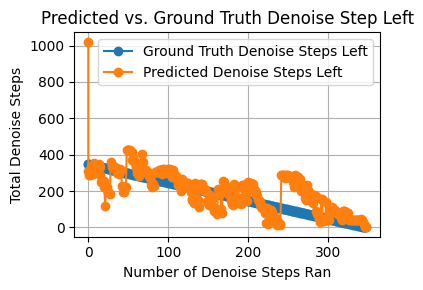

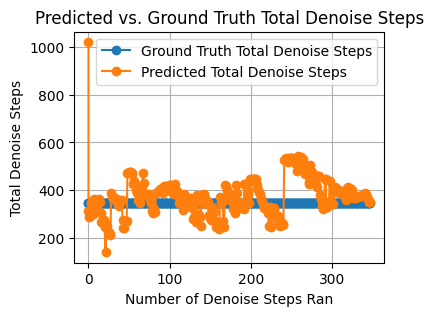

In [13]:
# for a random request, visualize its predicted total denoise steps vs. ground truth total denoise steps across the denoise iterations
random_id = results_df["id"].sample(n=1, random_state=39).iloc[0]
request_df = results_df[results_df["id"] == random_id].sort_values("num_denoise_ran")
plt.figure(figsize=(4, 3))
# plt.plot(request_df["num_denoise_ran"], request_df["ground_truth_total_denoise_steps"], label="Ground Truth Total Denoise Steps", marker='o')
# plt.plot(request_df["num_denoise_ran"], request_df["predicted_total_denoise_steps"], label="Predicted Total Denoise Steps", marker='o')
# plot steps left instead
plt.plot(request_df["num_denoise_ran"], request_df["ground_truth_denoise_steps_left"], label="Ground Truth Denoise Steps Left", marker='o')
plt.plot(request_df["num_denoise_ran"], request_df["predicted_denoise_steps_left"], label="Predicted Denoise Steps Left", marker='o')
plt.xlabel("Number of Denoise Steps Ran")
plt.ylabel("Total Denoise Steps")
plt.title(f"Predicted vs. Ground Truth Denoise Step Left")
plt.legend()
plt.grid()
plt.tight_layout()

# plot total denoise steps instead
plt.figure(figsize=(4, 3))
plt.plot(request_df["num_denoise_ran"], request_df["ground_truth_total_denoise_steps"], label="Ground Truth Total Denoise Steps", marker='o')
plt.plot(request_df["num_denoise_ran"], request_df["predicted_total_denoise_steps"], label="Predicted Total Denoise Steps", marker='o')
plt.xlabel("Number of Denoise Steps Ran")
plt.ylabel("Total Denoise Steps")
plt.title(f"Predicted vs. Ground Truth Total Denoise Steps")
plt.legend()
plt.grid()

Average WMAPE of the second entry of each request: 0.2277


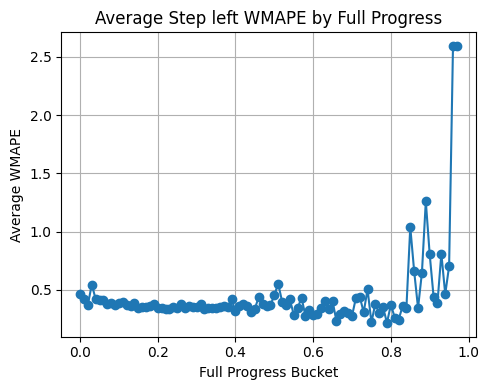

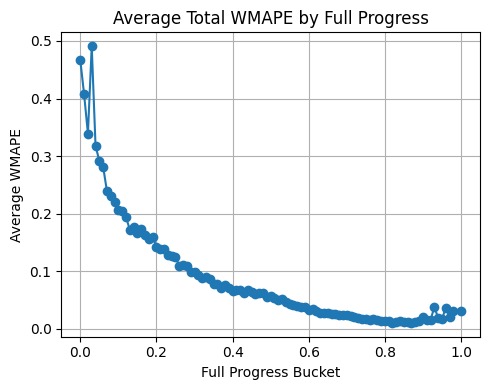

In [14]:
# print the average wmape of the second entry of each request
filtered_results = results_df[results_df["num_denoise_ran"] == 20]
wmape_per_request = _get_wmape_per_request(filtered_results, "ground_truth_total_denoise_steps", "predicted_total_denoise_steps")
print(f"Average WMAPE of the second entry of each request: {wmape_per_request:.4f}")


## # plot num_denoise_ran vs. average wmape
# wmape_by_denoise_ran = results_df.groupby("num_denoise_ran").apply(
#     lambda group: _get_wmape_per_request(group, "ground_truth_total_denoise_steps", "predicted_total_denoise_steps")
# )
# plt.figure(figsize=(8, 5))
# plt.plot(wmape_by_denoise_ran.index, wmape_by_denoise_ran.values, marker='o')
# plt.xlabel("Number of Denoise Steps Ran")
# plt.ylabel("Average WMAPE")
# plt.title("Average WMAPE by Number of Denoise Steps Ran")
# plt.grid()
# plt.tight_layout()

# silent warning
pd.options.mode.chained_assignment = None  # default='warn'
# df warning
pd.set_option('mode.chained_assignment', None)

# plot full progress vs. average wmape
# round full progress to nearest 0.01 bucket
results_df["full_progress_bucket"] = (results_df["full_progress"] * 100).round() / 100
# wmape_by_full_progress = results_df.groupby("full_progress_bucket").apply(
#     lambda group: _get_wmape_per_request(group, "ground_truth_total_denoise_steps", "predicted_total_denoise_steps")
# )
# use step left
wmape_by_full_progress = results_df.groupby("full_progress_bucket").apply(
    lambda group: _get_wmape_per_request(group, "ground_truth_denoise_steps_left", "predicted_denoise_steps_left"),
    include_groups=False,
)
plt.figure(figsize=(5, 4))
plt.plot(wmape_by_full_progress.index, wmape_by_full_progress.values, marker='o')
plt.xlabel("Full Progress Bucket")
plt.ylabel("Average WMAPE")
plt.title("Average Step left WMAPE by Full Progress")
plt.grid()
plt.tight_layout()

wmape_by_full_progress = results_df.groupby("full_progress_bucket").apply(
    lambda group: _get_wmape_per_request(group, "ground_truth_total_denoise_steps", "predicted_total_denoise_steps"),
    include_groups=False,
)
plt.figure(figsize=(5, 4))
plt.plot(wmape_by_full_progress.index, wmape_by_full_progress.values, marker='o')
plt.xlabel("Full Progress Bucket")
plt.ylabel("Average WMAPE")
plt.title("Average Total WMAPE by Full Progress")
plt.grid()
plt.tight_layout()

## Start-Row Extrapolation Analysis

Evaluate a simpler baseline where each request is predicted only from its first row, then later steps use `x - num_denoise_ran`.

In [15]:
def evaluate_start_row_extrapolation(
    results_df: pd.DataFrame,
    model,
    included_features: list[str],
    objective: str = "denoise_ratio",
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Predict once from each request's start row and extrapolate later rows."""
    start_rows = (
        results_df.sort_values(["id", "num_denoise_ran"])
        .groupby("id", sort=False)
        .head(1)
        .copy()
    )

    start_features = start_rows[included_features]
    start_rows["start_row_predicted_denoise_ratio"] = model.predict(start_features)
    start_rows["start_row_predicted_denoise_steps_left"] = (
        start_rows["start_row_predicted_denoise_ratio"] * start_rows["output_length"]
    )
    start_rows["start_row_predicted_total_denoise_steps"] = (
        start_rows["start_row_predicted_denoise_steps_left"] + start_rows["num_denoise_ran"]
    )

    extrapolated = results_df.merge(
        start_rows[[
            "id",
            "start_row_predicted_denoise_ratio",
            "start_row_predicted_denoise_steps_left",
            "start_row_predicted_total_denoise_steps",
        ]],
        on="id",
        how="left",
    ).copy()

    extrapolated["start_row_extrapolated_denoise_steps_left"] = (
        extrapolated["start_row_predicted_denoise_steps_left"] - extrapolated["num_denoise_ran"]
    ).clip(lower=0.0)
    extrapolated["start_row_extrapolated_total_denoise_steps"] = (
        extrapolated["start_row_predicted_denoise_steps_left"]
    ).clip(lower=0.0)

    extrapolated["start_row_extrapolated_denoise_ratio"] = (
        extrapolated["start_row_extrapolated_denoise_steps_left"]
        / extrapolated["output_length"]
    )

    extrapolated["start_row_step_left_error"] = (
        extrapolated["start_row_extrapolated_denoise_steps_left"]
        - extrapolated["ground_truth_denoise_steps_left"]
    ) / extrapolated["ground_truth_denoise_steps_left"].replace(0, np.nan)
    extrapolated["start_row_total_step_error"] = (
        extrapolated["start_row_extrapolated_total_denoise_steps"]
        - extrapolated["ground_truth_total_denoise_steps"]
    ) / extrapolated["ground_truth_total_denoise_steps"].replace(0, np.nan)

    metrics: dict[str, float] = {
        "start_row_steps_left_WMAPE_per_request": _get_wmape_per_request(
            extrapolated,
            "ground_truth_denoise_steps_left",
            "start_row_extrapolated_denoise_steps_left",
        ),
        "start_row_steps_left_aggregate_WMAPE": _get_aggregate_wmape(
            extrapolated,
            "ground_truth_denoise_steps_left",
            "start_row_extrapolated_denoise_steps_left",
        ),
        "start_row_steps_left_Coverage": _get_coverage(
            extrapolated,
            "ground_truth_denoise_steps_left",
            "start_row_extrapolated_denoise_steps_left",
        ),
        "start_row_steps_left_QCE": _get_qce(
            extrapolated,
            "ground_truth_denoise_steps_left",
            "start_row_extrapolated_denoise_steps_left",
        ),
        "start_row_steps_left_RMSE": _get_rmse(
            extrapolated,
            "ground_truth_denoise_steps_left",
            "start_row_extrapolated_denoise_steps_left",
        ),
        "start_row_steps_left_R^2": _get_r2(
            extrapolated,
            "ground_truth_denoise_steps_left",
            "start_row_extrapolated_denoise_steps_left",
        ),
        "start_row_total_steps_WMAPE_per_request": _get_wmape_per_request(
            extrapolated,
            "ground_truth_total_denoise_steps",
            "start_row_extrapolated_total_denoise_steps",
        ),
        "start_row_total_steps_aggregate_WMAPE": _get_aggregate_wmape(
            extrapolated,
            "ground_truth_total_denoise_steps",
            "start_row_extrapolated_total_denoise_steps",
        ),
        "start_row_total_steps_Coverage": _get_coverage(
            extrapolated,
            "ground_truth_total_denoise_steps",
            "start_row_extrapolated_total_denoise_steps",
        ),
        "start_row_total_steps_QCE": _get_qce(
            extrapolated,
            "ground_truth_total_denoise_steps",
            "start_row_extrapolated_total_denoise_steps",
        ),
        "start_row_total_steps_RMSE": _get_rmse(
            extrapolated,
            "ground_truth_total_denoise_steps",
            "start_row_extrapolated_total_denoise_steps",
        ),
        "start_row_total_steps_R^2": _get_r2(
            extrapolated,
            "ground_truth_total_denoise_steps",
            "start_row_extrapolated_total_denoise_steps",
        ),
    }

    return extrapolated, metrics


start_row_results_df, start_row_metrics = evaluate_start_row_extrapolation(
    results_df,
    model,
    included_features,
)

print("Start-row extrapolation metrics:")
for key, value in start_row_metrics.items():
    print(f"  {key}: {value:.4f}")

comparison_rows = [
    {
        "metric": "Steps left WMAPE per request",
        "current_model": metrics["Steps left WMAPE per request"],
        "start_row_extrapolation": start_row_metrics["start_row_steps_left_WMAPE_per_request"],
    },
    {
        "metric": "Steps left aggregate WMAPE",
        "current_model": metrics["Steps left Aggregate WMAPE"],
        "start_row_extrapolation": start_row_metrics["start_row_steps_left_aggregate_WMAPE"],
    },
    {
        "metric": "Steps left coverage",
        "current_model": metrics["Steps left Coverage"],
        "start_row_extrapolation": start_row_metrics["start_row_steps_left_Coverage"],
    },
    {
        "metric": "Steps left RMSE",
        "current_model": metrics["Steps left RMSE"],
        "start_row_extrapolation": start_row_metrics["start_row_steps_left_RMSE"],
    },
    {
        "metric": "Total steps WMAPE per request",
        "current_model": metrics["Total steps WMAPE per request"],
        "start_row_extrapolation": start_row_metrics["start_row_total_steps_WMAPE_per_request"],
    },
    {
        "metric": "Total steps aggregate WMAPE",
        "current_model": metrics["Total steps Aggregate WMAPE"],
        "start_row_extrapolation": start_row_metrics["start_row_total_steps_aggregate_WMAPE"],
    },
    {
        "metric": "Total steps coverage",
        "current_model": metrics["Total steps Coverage"],
        "start_row_extrapolation": start_row_metrics["start_row_total_steps_Coverage"],
    },
    {
        "metric": "Total steps RMSE",
        "current_model": metrics["Total steps RMSE"],
        "start_row_extrapolation": start_row_metrics["start_row_total_steps_RMSE"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

Start-row extrapolation metrics:
  start_row_steps_left_WMAPE_per_request: 1.5827
  start_row_steps_left_aggregate_WMAPE: 0.5846
  start_row_steps_left_Coverage: 0.3159
  start_row_steps_left_QCE: 0.4841
  start_row_steps_left_RMSE: 109.3642
  start_row_steps_left_R^2: -0.5197
  start_row_total_steps_WMAPE_per_request: 0.8865
  start_row_total_steps_aggregate_WMAPE: 0.3184
  start_row_total_steps_Coverage: 0.3117
  start_row_total_steps_QCE: 0.4883
  start_row_total_steps_RMSE: 112.0244
  start_row_total_steps_R^2: 0.0654


,metric,current_model,start_row_extrapolation
0,Steps left WMAPE per request,0.606215,1.582689
1,Steps left aggregate WMAPE,0.234148,0.584607
2,Steps left coverage,0.486807,0.315890
3,Steps left RMSE,38.177615,109.364216
4,Total steps WMAPE per request,0.334378,0.886515
5,Total steps aggregate WMAPE,0.117650,0.318367
6,Total steps coverage,0.486807,0.311667
7,Total steps RMSE,38.177615,112.024444


In [16]:
start_row_results_df["start_row_extrapolated_denoise_steps_left"][:500]
# no truncation
print(start_row_results_df[["id", "num_denoise_ran", "ground_truth_denoise_steps_left", "start_row_extrapolated_denoise_steps_left"]].head(20))

                                                   id  num_denoise_ran  \
0   /work/hdd/bftv/tchang85/step_predictor_dataset...                0   
1   /work/hdd/bftv/tchang85/step_predictor_dataset...                0   
2   /work/hdd/bftv/tchang85/step_predictor_dataset...                1   
3   /work/hdd/bftv/tchang85/step_predictor_dataset...                2   
4   /work/hdd/bftv/tchang85/step_predictor_dataset...                3   
5   /work/hdd/bftv/tchang85/step_predictor_dataset...                4   
6   /work/hdd/bftv/tchang85/step_predictor_dataset...                5   
7   /work/hdd/bftv/tchang85/step_predictor_dataset...                6   
8   /work/hdd/bftv/tchang85/step_predictor_dataset...                7   
9   /work/hdd/bftv/tchang85/step_predictor_dataset...                8   
10  /work/hdd/bftv/tchang85/step_predictor_dataset...                9   
11  /work/hdd/bftv/tchang85/step_predictor_dataset...               10   
12  /work/hdd/bftv/tchang85/step_predi

## Plotting
Render the diagnostic plots separately so they can be rerun without retraining.

### prepare plot df

#### function

In [17]:
def _prepare_plot_df(results_df: pd.DataFrame) -> pd.DataFrame:
    plot_df = results_df.copy()
    plot_df["full_unmask_progress_rounded"] = plot_df["full_unmask_progress"].round(1)
    plot_df["masked_tokens_left"] = plot_df["output_length"] - plot_df["num_unmasked_tokens"]
    # plot_df["error"] = (plot_df["y_pred_steps"] - plot_df["y_test_steps"]) / plot_df["y_test_steps"]
    plot_df["step_left_error"] = (plot_df["predicted_denoise_steps_left"] - plot_df["ground_truth_denoise_steps_left"]) / plot_df["ground_truth_denoise_steps_left"].replace(0, np.nan)
    plot_df["total_step_error"] = (plot_df["predicted_total_denoise_steps"] - plot_df["ground_truth_total_denoise_steps"]) / plot_df["ground_truth_total_denoise_steps"].replace(0, np.nan)
    return plot_df

#### run

In [18]:
plot_df = _prepare_plot_df(results_df)

### plot_error_vs_progress

#### function

In [19]:
def plot_total_step_error_vs_progress(plot_df: pd.DataFrame, title_suffix: str = "") -> None:
    plt.figure(figsize=(10, 5))
    plot_df.boxplot(column="total_step_error", by="full_unmask_progress_rounded", grid=False, showfliers=False)
    plt.ylim(-1, 1)
    plt.xlabel("Full Denoise Progress (rounded)")
    plt.ylabel("Prediction Error")
    plt.title(f"Prediction Error vs Full Denoise Progress{title_suffix}")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig("denoise_ratio_error_vs_progress.png", dpi=300)
    
def plot_step_left_error_vs_progress(plot_df: pd.DataFrame, title_suffix: str = "") -> None:
    plt.figure(figsize=(10, 5))
    plot_df.boxplot(column="step_left_error", by="full_unmask_progress_rounded", grid=False, showfliers=False)
    plt.ylim(-1, 1)
    plt.xlabel("Full Denoise Progress (rounded)")
    plt.ylabel("Step Left Prediction Error")
    plt.title(f"Step Left Prediction Error vs Full Denoise Progress{title_suffix}")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig("step_left_error_vs_progress.png", dpi=300)

#### run

<Figure size 1000x500 with 0 Axes>

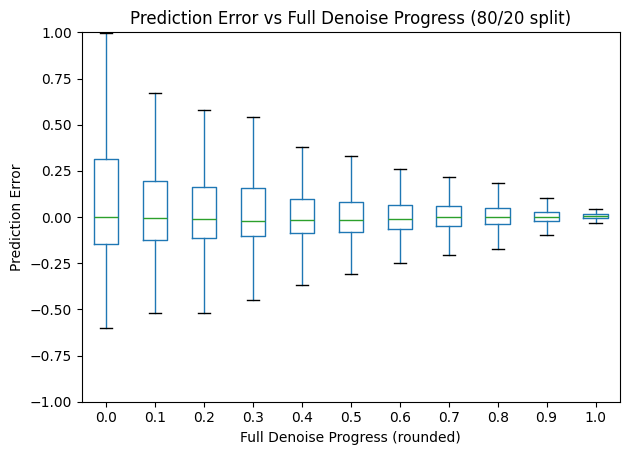

<Figure size 1000x500 with 0 Axes>

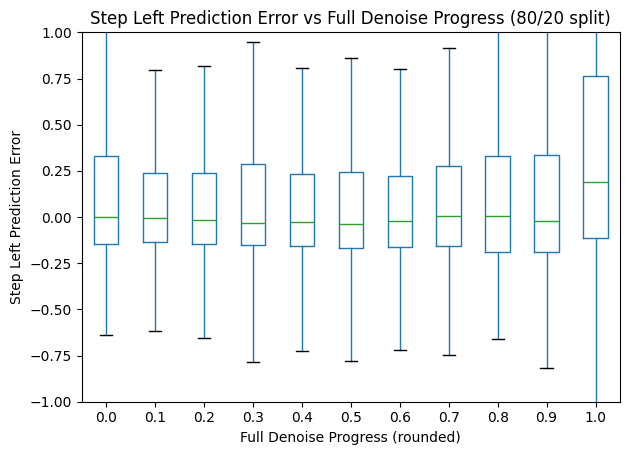

In [20]:
plot_total_step_error_vs_progress(plot_df, title_suffix=title_suffix)
plot_step_left_error_vs_progress(plot_df, title_suffix=title_suffix)

### plot_steps_left

#### function

In [21]:
def plot_steps_left(plot_df: pd.DataFrame, title_suffix: str = "") -> None:
    plt.figure(figsize=(6, 5))
    plt.scatter(plot_df["num_unmasked_tokens"], plot_df["ground_truth_denoise_steps_left"], alpha=0.3, label="Actual")
    plt.scatter(plot_df["num_unmasked_tokens"], plot_df["predicted_denoise_steps_left"], alpha=0.3, label="Predicted")
    plt.xlabel("Num Unmasked Tokens")
    plt.ylabel("Num Denoise Steps Left")
    plt.title(f"Predicted vs Actual Denoise Steps Left{title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("denoise_steps_prediction.png", dpi=300)

#### run

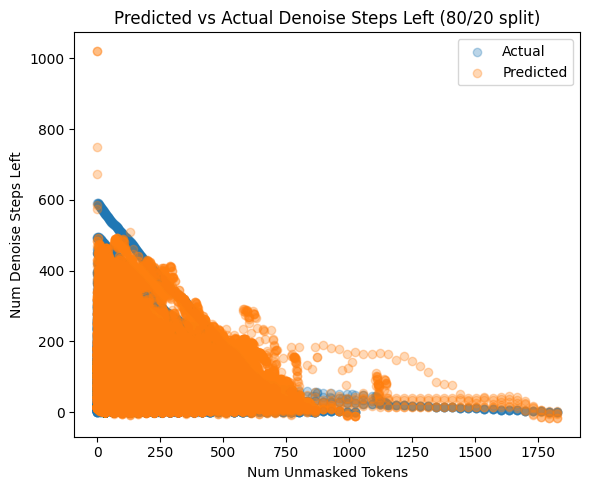

In [22]:
plot_steps_left(plot_df, title_suffix=title_suffix)

### plot_ratio_prediction

#### function

In [23]:
def plot_ratio_prediction(plot_df: pd.DataFrame, y_test: pd.Series, y_pred: np.ndarray, title_suffix: str = "") -> None:
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.xlabel("Actual Denoise Ratio")
    plt.ylabel("Predicted Denoise Ratio")
    for threshold in plot_df["confidence_threshold"].unique():
        subset = plot_df[plot_df["confidence_threshold"] == threshold]
        plt.scatter(subset["y_test_ratio"], subset["y_pred_ratio"], alpha=0.3, label=f"Threshold {threshold}")
    plt.legend(title="Confidence Threshold")
    plt.title(f"Predicted vs Actual Denoise Ratio{title_suffix}")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.tight_layout()
    plt.savefig("denoise_ratio_prediction.png", dpi=300)

#### run

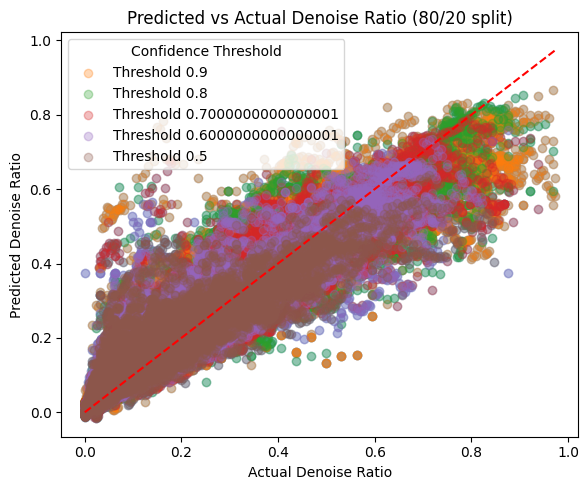

In [24]:
plot_ratio_prediction(plot_df, y_test, y_pred, title_suffix=title_suffix)

### plot_output_confidence

#### function

In [25]:
def plot_output_confidence(plot_df: pd.DataFrame, title_suffix: str = "") -> None:
    plt.figure(figsize=(6, 5))
    plt.scatter(plot_df["output_avg_confidence"], plot_df["y_test_ratio"], alpha=0.3)
    plt.xlabel("Output Average Confidence")
    plt.ylabel("Actual Denoise Ratio")
    plt.title(f"Output Average Confidence vs Actual Denoise Ratio{title_suffix}")
    plt.tight_layout()
    plt.savefig("output_avg_confidence_vs_denoise_ratio.png", dpi=300)

#### run

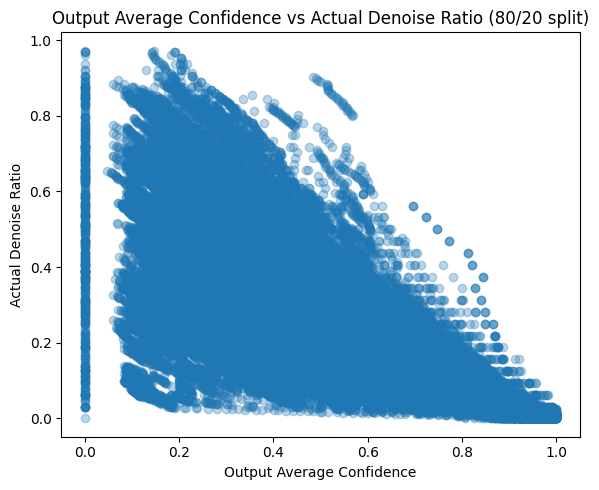

In [26]:
plot_output_confidence(plot_df, title_suffix=title_suffix)

### Plot Changes in Prediction at Granularity

/tmp/ipykernel_389221/3926507762.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=[str(step) for step in ordered_steps], showfliers=False)


,count,mean,std,min,25%,50%,75%,max
step_granularity,,,,,,,,
1,60594.0,0.023674,0.055750,5.281978e-07,0.003484,0.008333,0.022017,2.858992
2,60094.0,0.033596,0.068223,2.476062e-07,0.005703,0.013856,0.034170,3.185690
4,59103.0,0.046551,0.080231,1.392283e-06,0.008958,0.021997,0.051794,4.578985
8,57184.0,0.061465,0.090731,9.663943e-07,0.013494,0.033003,0.073558,3.169717
16,53483.0,0.075231,0.096458,1.052095e-06,0.018558,0.044065,0.094990,1.929821
32,46770.0,0.091113,0.107073,4.808834e-08,0.026011,0.058487,0.118090,2.387867


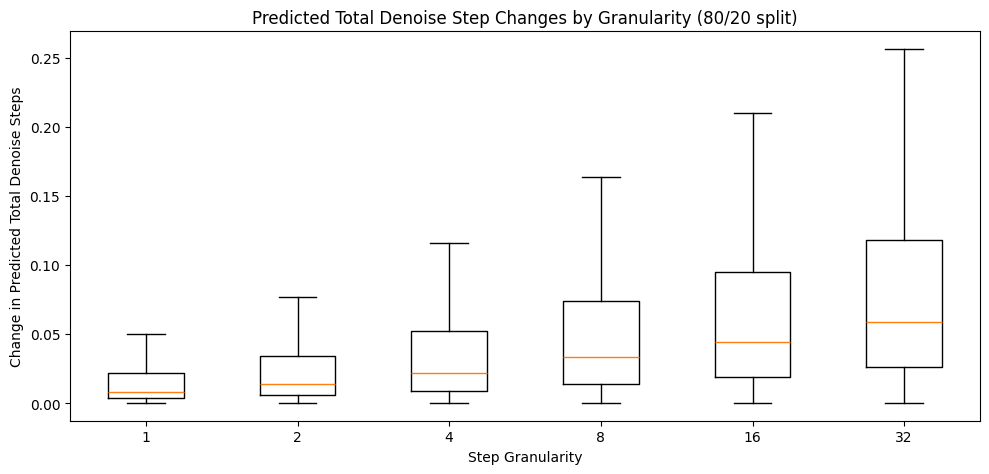

In [27]:
def _prepare_prediction_delta_by_granularity(plot_df: pd.DataFrame, step_granularities: list[int]) -> pd.DataFrame:
    rows = []
    sorted_df = plot_df.sort_values(["id", "num_denoise_ran"])

    for step_granularity in step_granularities:
        for _, group in sorted_df.groupby("id", sort=False):
            group = group.sort_values("num_denoise_ran")
            prev = group["predicted_total_denoise_steps"].shift(step_granularity)
            delta = (
                abs((group["predicted_total_denoise_steps"] - prev))
                / prev.replace(0, np.nan)
            ).replace([np.inf, -np.inf], np.nan).dropna()
            if delta.empty:
                continue

            rows.extend(
                {
                    "step_granularity": step_granularity,
                    "predicted_total_steps_change": float(abs(value)),
                }
                for value in delta
            )

    if not rows:
        return pd.DataFrame(columns=["step_granularity", "predicted_total_steps_change"])

    return pd.DataFrame(rows)


def plot_prediction_changes_at_granularity(
    plot_df: pd.DataFrame,
    title_suffix: str = "",
    step_granularities: list[int] | None = None,
) -> pd.DataFrame:
    if step_granularities is None:
        step_granularities = [1, 2, 4, 8, 16, 32]

    delta_df = _prepare_prediction_delta_by_granularity(plot_df, step_granularities)
    if delta_df.empty:
        print("No prediction delta data available for the requested step granularities.")
        return delta_df

    ordered_steps = [step for step in step_granularities if step in delta_df["step_granularity"].unique()]
    box_data = [
        delta_df.loc[delta_df["step_granularity"] == step, "predicted_total_steps_change"].values
        for step in ordered_steps
    ]

    plt.figure(figsize=(10, 5))
    plt.boxplot(box_data, labels=[str(step) for step in ordered_steps], showfliers=False)
    plt.xlabel("Step Granularity")
    plt.ylabel("Change in Predicted Total Denoise Steps")
    plt.title(f"Predicted Total Denoise Step Changes by Granularity{title_suffix}")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig("predicted_total_steps_changes_at_granularity.png", dpi=300)

    return delta_df


delta_df = plot_prediction_changes_at_granularity(plot_df, title_suffix=title_suffix)
delta_df.groupby("step_granularity")["predicted_total_steps_change"].apply(lambda s: s.abs().describe()).unstack()

### Prediction Delta by Current Unmasked Tokens

This section groups step-to-step changes in predicted total denoise steps by `num_cur_unmasked_tokens` and boxplots those deltas across all requests.

/tmp/ipykernel_389221/1451697059.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=[str(token_count) for token_count in ordered_tokens], showfliers=False)


,count,mean,std,min,25%,50%,75%,max
num_cur_unmasked_tokens,,,,,,,,
1,45133.0,1.779835,4.520888,0.000053,0.308009,0.680694,1.662888,285.899209
2,5604.0,2.307925,4.544248,0.000344,0.364999,0.974396,2.329556,109.068625
3,2907.0,3.100651,5.558076,0.000607,0.566959,1.405352,3.282236,89.704340
4,1775.0,3.564559,5.844975,0.001796,0.702468,1.676324,3.858409,67.363183
5,1121.0,4.621324,8.290207,0.000509,1.106577,2.163192,4.734691,98.339916
6,790.0,5.192933,7.811164,0.008603,1.275033,2.919357,5.839322,89.521430
7,516.0,4.790094,6.180735,0.011563,1.242568,2.698931,6.063000,53.397755
8,387.0,6.520367,8.736091,0.037585,1.785487,3.660703,7.287527,71.924923
9,242.0,6.781590,7.750280,0.012495,2.437781,4.382827,7.902483,51.906748


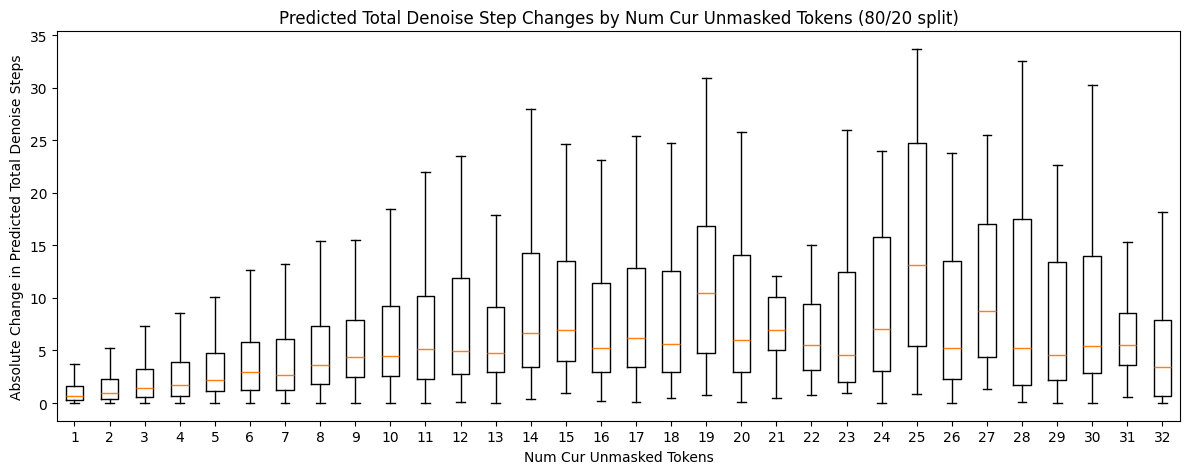

In [28]:
def _prepare_prediction_delta_by_cur_unmasked_tokens(plot_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    sorted_df = plot_df.sort_values(["id", "num_denoise_ran"])

    for _, group in sorted_df.groupby("id", sort=False):
        group = group.sort_values("num_denoise_ran")
        delta = (group["predicted_total_denoise_steps"] - group["predicted_total_denoise_steps"].shift(1)).abs()
        valid_mask = delta.notna()
        if not valid_mask.any():
            continue

        prev = group["predicted_total_denoise_steps"].shift(1)
        pct_change = (
            (group["predicted_total_denoise_steps"] - prev).abs()
            / prev.replace(0, np.nan)
            * 100.0
        )

        rows.extend(
            {
            "num_cur_unmasked_tokens": int(token_count),
            "predicted_total_steps_change": float(change),
            }
            for token_count, change in zip(
            group.loc[pct_change.notna(), "num_cur_unmasked_tokens"],
            pct_change.dropna(),
            )
        )

    if not rows:
        return pd.DataFrame(columns=["num_cur_unmasked_tokens", "predicted_total_steps_change"])

    return pd.DataFrame(rows)


def plot_prediction_changes_by_cur_unmasked_tokens(
    plot_df: pd.DataFrame,
    title_suffix: str = "",
) -> pd.DataFrame:
    delta_df = _prepare_prediction_delta_by_cur_unmasked_tokens(plot_df)
    if delta_df.empty:
        print("No prediction delta data available for the requested unmasked-token analysis.")
        return delta_df

    ordered_tokens = sorted(delta_df["num_cur_unmasked_tokens"].unique())
    box_data = [
        delta_df.loc[delta_df["num_cur_unmasked_tokens"] == token_count, "predicted_total_steps_change"].values
        for token_count in ordered_tokens
    ]

    plt.figure(figsize=(12, 5))
    plt.boxplot(box_data, labels=[str(token_count) for token_count in ordered_tokens], showfliers=False)
    plt.xlabel("Num Cur Unmasked Tokens")
    plt.ylabel("Absolute Change in Predicted Total Denoise Steps")
    plt.title(f"Predicted Total Denoise Step Changes by Num Cur Unmasked Tokens{title_suffix}")
    plt.suptitle("")
    plt.tight_layout()
    plt.savefig("predicted_total_steps_changes_by_cur_unmasked_tokens.png", dpi=300)

    return delta_df


delta_unmasked_df = plot_prediction_changes_by_cur_unmasked_tokens(plot_df, title_suffix=title_suffix)
delta_unmasked_df.groupby("num_cur_unmasked_tokens")["predicted_total_steps_change"].describe()

In [29]:
sanity_output_lengths = [32, 64, 128, 256, 512, 1024, 2048]

sanity_df = df[df["output_length"].isin(sanity_output_lengths)].copy()
sanity_df = sanity_df.sort_values(["output_length", "confidence_threshold", "id", "num_denoise_ran"]).reset_index(drop=True)

start_rows = sanity_df[sanity_df["num_denoise_ran"] == 0].copy()
start_rows = start_rows.sort_values(["output_length", "confidence_threshold", "id"]).groupby(
    ["output_length", "confidence_threshold"], as_index=False
).head(1).reset_index(drop=True)

print(f"Selected start rows: {len(start_rows)}")
print("One start row per output length / confidence threshold pair:")
display(start_rows)

start_features = start_rows[included_features]
start_predictions = model.predict(start_features)

prediction_results = start_rows[[
    "id",
    "output_length",
    "confidence_threshold",
    "num_denoise_ran",
    "num_unmasked_tokens",
]].copy()
prediction_results["predicted_denoise_ratio"] = start_predictions
prediction_results["predicted_denoise_steps_left"] = (
    prediction_results["predicted_denoise_ratio"] * prediction_results["output_length"]
)
prediction_results["predicted_total_denoise_steps"] = (
    prediction_results["predicted_denoise_steps_left"] + prediction_results["num_denoise_ran"]
)

print("\nPredictions for the start rows:")
display(prediction_results)


Selected start rows: 30
One start row per output length / confidence threshold pair:


,source_file,id,confidence_threshold,num_unmasked_tokens,num_cur_unmasked_tokens,output_length,block_size,block,block_num_unmasked_tokens,num_denoise_ran,num_denoise_left,full_progress,full_unmask_progress,full_cur_unmask_progress,block_progress,block_unmask_progress,denoise_ratio,last_recompute_avg_output_confidence,cur_avg_output_confidence,output_min_confidence,output_q25_confidence,output_median_confidence,output_avg_confidence,output_q75_confidence
0,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.5,0,0.0,32,32,0,0,0,0,0.031250,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.6,0,0.0,32,32,0,0,0,2,0.031250,0.0,0.0,0.0,0.0,0.062500,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.7,0,0.0,32,32,0,0,0,4,0.031250,0.0,0.0,0.0,0.0,0.125000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.8,0,0.0,32,32,0,0,0,3,0.031250,0.0,0.0,0.0,0.0,0.093750,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,0,0.0,32,32,0,0,0,3,0.031250,0.0,0.0,0.0,0.0,0.093750,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.5,0,0.0,64,32,0,0,0,41,0.015625,0.0,0.0,0.0,0.0,0.640625,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.6,0,0.0,64,32,0,0,0,50,0.015625,0.0,0.0,0.0,0.0,0.781250,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.7,0,0.0,64,32,0,0,0,28,0.015625,0.0,0.0,0.0,0.0,0.437500,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.8,0,0.0,64,32,0,0,0,62,0.015625,0.0,0.0,0.0,0.0,0.968750,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,/work/hdd/bftv/tchang85/step_predictor_dataset...,/work/hdd/bftv/tchang85/step_predictor_dataset...,0.9,0,0.0,64,32,0,0,0,29,0.015625,0.0,0.0,0.0,0.0,0.453125,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Predictions for the start rows:


,id,output_length,confidence_threshold,num_denoise_ran,num_unmasked_tokens,predicted_denoise_ratio,predicted_denoise_steps_left,predicted_total_denoise_steps
0,/work/hdd/bftv/tchang85/step_predictor_dataset...,32,0.5,0,0,0.314459,10.062697,10.062697
1,/work/hdd/bftv/tchang85/step_predictor_dataset...,32,0.6,0,0,0.373521,11.952684,11.952684
2,/work/hdd/bftv/tchang85/step_predictor_dataset...,32,0.7,0,0,0.421542,13.489352,13.489352
3,/work/hdd/bftv/tchang85/step_predictor_dataset...,32,0.8,0,0,0.468875,15.003988,15.003988
4,/work/hdd/bftv/tchang85/step_predictor_dataset...,32,0.9,0,0,0.557328,17.834504,17.834504
5,/work/hdd/bftv/tchang85/step_predictor_dataset...,64,0.5,0,0,0.440001,28.160067,28.160067
6,/work/hdd/bftv/tchang85/step_predictor_dataset...,64,0.6,0,0,0.499063,31.940042,31.940042
7,/work/hdd/bftv/tchang85/step_predictor_dataset...,64,0.7,0,0,0.547084,35.013379,35.013379
8,/work/hdd/bftv/tchang85/step_predictor_dataset...,64,0.8,0,0,0.594416,38.042650,38.042650
9,/work/hdd/bftv/tchang85/step_predictor_dataset...,64,0.9,0,0,0.667303,42.707422,42.707422
